# DataSet Mering and feature engineering

In [1]:
# LOAD, MERGE & COLLAPSE (Causal Logic - Pre-Hospital Assistance)
import pandas as pd
import numpy as np
import re
from pathlib import Path


EMB_PATH = Path("../data/processed/08.FRAIL_with_tsvd_10dim.csv")
LLM_PATH = Path("../data/processed/09.llm.csv")
DROP_PERCENTILES = False

# 1) Read Files
emb = pd.read_csv(EMB_PATH) 
llm = pd.read_csv(LLM_PATH)
print(f"Loaded embeddings: {EMB_PATH} | shape={emb.shape}")
print(f"Loaded LLM:        {LLM_PATH} | shape={llm.shape}")

# 2) Check Keys
for k in ["ID_Aluno", "Momento"]:
    if k not in emb.columns or k not in llm.columns:
        raise KeyError(f"Missing key '{k}' in one of the files. emb has={k in emb.columns}, llm has={k in llm.columns}")

# 3) Enforce Key Types
for k in ["ID_Aluno", "Momento"]:
    emb[k] = pd.to_numeric(emb[k], errors="coerce").astype("Int64")
    llm[k] = pd.to_numeric(llm[k], errors="coerce").astype("Int64")

# 4) Deduplicate within files first
if emb.duplicated(subset=["ID_Aluno","Momento"]).any():
    emb = (emb.sort_values(["ID_Aluno","Momento"])
              .drop_duplicates(subset=["ID_Aluno","Momento"], keep="first"))
if llm.duplicated(subset=["ID_Aluno","Momento"]).any():
    llm = (llm.sort_values(["ID_Aluno","Momento"])
              .drop_duplicates(subset=["ID_Aluno","Momento"], keep="first"))

# 5) Merge
df = emb.merge(llm, on=["ID_Aluno","Momento"], how="left", suffixes=("", "_llmdup"))
dup_cols = [c for c in df.columns if c.endswith("_llmdup")]
if dup_cols:
    df = df.drop(columns=dup_cols)

# 6) Remove Percentile Columns
if DROP_PERCENTILES:
    pct_cols = [c for c in df.columns if re.search(r"percentil|percentile", c, flags=re.I)]
    if pct_cols:
        df = df.drop(columns=pct_cols)
        print(f"Dropped percentile columns: {len(pct_cols)}")

print(f"Merged shape: {df.shape}")


# 7) COLLAPSE TO 1 ROW PER ID_ALUNO (Causal Logic)
#    - Nunca teve assistência hospitalar                                   → primeiro momento, label=0
#    - Teve assistência nalgum momento                                     → último momento ANTES da 1ª assistência, label=1
#    - Sem registo limpo antes do evento (inclui só 1 registo com assist.) → excluir

PREF_TARGET_COL = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

if PREF_TARGET_COL not in df.columns:
    found = [c for c in df.columns if c.lower() == PREF_TARGET_COL.lower()]
    if found:
        PREF_TARGET_COL = found[0]
    else:
        raise KeyError(f"Column '{PREF_TARGET_COL}' not found after merge.")

map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, '1': 1, '0': 0, 1: 1, 0: 0}

df["_target_bin"] = df[PREF_TARGET_COL].map(map_dict)
df["_target_bin"] = df["_target_bin"].fillna(
    pd.to_numeric(df[PREF_TARGET_COL], errors="coerce")
).fillna(0).astype(int)

df["Momento"] = pd.to_numeric(df["Momento"], errors="coerce")
df = df.sort_values(["ID_Aluno", "Momento"]).reset_index(drop=True)

before_shape = df.shape
n_multi = (df["ID_Aluno"].value_counts() > 1).sum()
n_excluded = 0

rows_to_keep = []
for id_aluno, group in df.groupby("ID_Aluno"):
    group = group.sort_values("Momento")

    assist_moments    = group[group["_target_bin"] == 1]["Momento"]
    no_assist_records = group[group["_target_bin"] == 0]

    if len(assist_moments) == 0:
        # Nunca teve assistência → primeiro momento, label=0
        row = group.iloc[0].copy()
        rows_to_keep.append(row)

    else:
        first_assist  = assist_moments.min()
        before_assist = no_assist_records[no_assist_records["Momento"] < first_assist]

        if len(before_assist) == 0:
            # Sem registo limpo antes da assistência → excluir
            n_excluded += 1
            continue

        # Último momento antes da 1ª assistência, label=1
        row = before_assist.iloc[-1].copy()
        row[PREF_TARGET_COL] = "Sim"
        rows_to_keep.append(row)

df = (pd.DataFrame(rows_to_keep)
        .drop(columns=["_target_bin"])
        .reset_index(drop=True))

print("-" * 40)
print(f"COLLAPSE REPORT (Target: {PREF_TARGET_COL})")
print(f"Before collapse: {before_shape}")
print(f"After collapse:  {df.shape}")
print(f"IDs com >1 registo: {n_multi}")
print(f"IDs excluídos (sem registo pré-assistência): {n_excluded}")
n_assist = df[PREF_TARGET_COL].map(map_dict).fillna(0).sum()
print(f"Com assistência hospitalar (label=1): {int(n_assist)}")
print(f"Sem assistência hospitalar (label=0): {len(df) - int(n_assist)}")
print("-" * 40)

Loaded embeddings: ..\data\processed\08.FRAIL_with_tsvd_10dim.csv | shape=(6705, 111)
Loaded LLM:        ..\data\processed\09.llm.csv | shape=(6705, 74)
Merged shape: (6705, 115)
----------------------------------------
COLLAPSE REPORT (Target: Quedas_12meses_Assistencia_hospitalar_Sim_Não)
Before collapse: (6705, 116)
After collapse:  (2666, 115)
IDs com >1 registo: 2051
IDs excluídos (sem registo pré-assistência): 178
Com assistência hospitalar (label=1): 144
Sem assistência hospitalar (label=0): 2522
----------------------------------------


In [2]:
# CLEAN HANDGRIP: Fix Typos, Calculate BEST, Drop Attempts
import re
import numpy as np
import pandas as pd

# Assuming 'df' is your main dataframe
df = df.copy()

print("--- Handgrip Cleaning Start ---")
print(f"Columns before: {len(df.columns)}")

# 1) Fix common typo: "tentaiva" -> "tentativa"
# This ensures regex matching works for all columns
df = df.rename(columns={"HANDGRIP_DIREITA_tentaiva1": "HANDGRIP_DIREITA_tentativa1"})

# 2) Identify Attempt Columns
hand_right_attempts = [c for c in df.columns if re.fullmatch(r"HANDGRIP_DIREITA_tentativa[123]", c)]
hand_left_attempts  = [c for c in df.columns if re.fullmatch(r"HANDGRIP_ESQUERDA_tentativa[123]", c)]

print(f"Right hand attempts found: {hand_right_attempts}")
print(f"Left hand attempts found:  {hand_left_attempts}")

# 3) Calculate Max per Hand
# We use max() because usually the best effort is what counts in frailty assessments
if hand_right_attempts:
    df["HANDGRIP_DIREITA_max"] = df[hand_right_attempts].astype(float).max(axis=1, skipna=True)

if hand_left_attempts:
    df["HANDGRIP_ESQUERDA_max"] = df[hand_left_attempts].astype(float).max(axis=1, skipna=True)

# 4) Calculate Global BEST (Max of Left vs Right)
cands = []
if "HANDGRIP_DIREITA_max" in df.columns: cands.append("HANDGRIP_DIREITA_max")
if "HANDGRIP_ESQUERDA_max" in df.columns: cands.append("HANDGRIP_ESQUERDA_max")

if cands:
    df["HANDGRIP_BEST"] = df[cands].max(axis=1, skipna=True)
    print("Created 'HANDGRIP_BEST' from:", cands)
else:
    print("Warning: Could not calculate HANDGRIP_BEST (no data found)")

# 5) Drop Raw Attempts & Old Means
# We want to keep the dataset clean, so we remove the intermediate steps
drop_hand_cols = []
drop_hand_cols += hand_right_attempts + hand_left_attempts
# Also drop old pre-calculated means if they exist
drop_hand_cols += [c for c in ["HANDGRIP_DIREITA_mean", "HANDGRIP_ESQUERDA_mean"] if c in df.columns]

# Drop intermediate max columns too? 
# Usually yes, unless you specifically want to analyze left vs right asymmetry later.
# For now, I will drop them to match your snippet's logic.
drop_hand_cols += [c for c in ["HANDGRIP_DIREITA_max", "HANDGRIP_ESQUERDA_max"] if c in df.columns]

if drop_hand_cols:
    df = df.drop(columns=drop_hand_cols, errors="ignore")
    print(f"Dropped {len(drop_hand_cols)} handgrip columns (attempts/means/intermediate max).")

# Verification
cols_to_show = [c for c in df.columns if "HANDGRIP" in c]
print(f"Final HANDGRIP columns: {cols_to_show}")
print(f"Columns after: {len(df.columns)}")
print("--- Handgrip Cleaning Done ---")


--- Handgrip Cleaning Start ---
Columns before: 115
Right hand attempts found: ['HANDGRIP_DIREITA_tentativa1', 'HANDGRIP_DIREITA_tentativa2']
Left hand attempts found:  ['HANDGRIP_ESQUERDA_tentativa1', 'HANDGRIP_ESQUERDA_tentativa2', 'HANDGRIP_ESQUERDA_tentativa3']
Created 'HANDGRIP_BEST' from: ['HANDGRIP_DIREITA_max', 'HANDGRIP_ESQUERDA_max']
Dropped 7 handgrip columns (attempts/means/intermediate max).
Final HANDGRIP columns: ['HANDGRIP_Mao_DOMINANTE', 'HANDGRIP_DIREITA_tentativa_3', 'HANDGRIP_BEST']
Columns after: 111
--- Handgrip Cleaning Done ---


In [3]:
# PRE-PROCESSING: TARGET = HOSPITAL ASSISTANCE
import re
import numpy as np
import pandas as pd

# Assuming 'df' is already loaded in your environment
df = df.copy()  # work on a copy

# 0) FILTERING: Handle Target NaNs First
TARGET = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

# Crucial: Remove rows where we don't know if they received assistance
print(f"Original shape: {df.shape}")
df = df.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df.shape}")

# 1) Attempts handling (BEST if present; else create/keep MEAN)
kept_all, dropped_all, created_all = [], [], []

def process_metric(df, attempts, best_col=None, mean_col=None, name="metric"):
    """Keep BEST if present; otherwise create/keep MEAN; drop attempts."""
    local_kept, local_dropped, local_created = [], [], []
    atts = [c for c in attempts if c in df.columns]

    if best_col and (best_col in df.columns):
        # BEST exists → keep it, drop attempts (+ mean if already existed)
        if mean_col and (mean_col in df.columns):
            df = df.drop(columns=[mean_col], errors="ignore")
            local_dropped.append(mean_col)
        if atts:
            df = df.drop(columns=atts, errors="ignore")
            local_dropped += atts
        local_kept.append(best_col)
        print(f"[{name}] Keeping BEST '{best_col}'. Dropped attempts: {atts}"
              + (f" and mean '{mean_col}'" if mean_col in local_dropped else ""))
    else:
        # No BEST → compute/keep MEAN (if there are attempts), then drop attempts
        if atts:
            if mean_col:
                df[mean_col] = df[atts].astype(float).mean(axis=1, skipna=True)
                local_kept.append(mean_col); local_created.append(mean_col)
                print(f"[{name}] No BEST. Created/kept MEAN '{mean_col}'.")
            df = df.drop(columns=atts, errors="ignore")
            local_dropped += atts
            print(f"[{name}] Dropped attempts: {atts}")
        else:
            print(f"[{name}] No BEST and no attempts found. Nothing to do.")

    kept_all.extend(local_kept); dropped_all.extend(local_dropped); created_all.extend(local_created)
    return df

# TUG (has Best_*)
df = process_metric(
    df,
    attempts=["TIMED_UP_AND_GO_Simples_tentativa1","TIMED_UP_AND_GO_Simples_tentativa2"],
    best_col="Best_TIMED_UP_AND_GO_Simples",
    mean_col="TIMED_UP_AND_GO_Simples_mean",
    name="TUG Simples"
)
df = process_metric(
    df,
    attempts=["TIMED_UP_AND_GO_Dupla_tarefa_tentativa1","TIMED_UP_AND_GO_Dupla_tarefa_tentativa2"],
    best_col="Best_TIMED_UP_AND_GO_Dupla_tarefa",
    mean_col="TIMED_UP_AND_GO_Dupla_tarefa_mean",
    name="TUG Dupla"
)

# Handgrip (no Best_* → keep MEAN, drop attempts) — tolerate typo 'tentaiva'
right_attempts = [c for c in df.columns if re.fullmatch(r"HANDGRIP_DIREITA_tent(at)?iva[123]", c)]
left_attempts  = [c for c in df.columns if re.fullmatch(r"HANDGRIP_ESQUERDA_tentativa[123]", c)]
df = process_metric(df, attempts=right_attempts, best_col=None, mean_col="HANDGRIP_DIREITA_mean", name="Handgrip Direita")
df = process_metric(df, attempts=left_attempts,  best_col=None, mean_col="HANDGRIP_ESQUERDA_mean", name="Handgrip Esquerda")

# Defensive: drop any leftover attempt columns
left_tent = [c for c in df.columns if re.search(r"tentativa", c, flags=re.I)]
if left_tent:
    df = df.drop(columns=left_tent, errors="ignore"); dropped_all += left_tent
    print(f"Dropped leftover attempt cols: {left_tent}")

print("\nKept summary columns:", kept_all)
print("Created means:", created_all)
print("Dropped (sample):", dropped_all[:15], "... total:", len(dropped_all))

# 2) Drop Percentil* (case-insensitive)
pct_cols = [c for c in df.columns if re.search(r"(?i)^percentil|percentile", c)]
if pct_cols:
    df = df.drop(columns=pct_cols, errors="ignore")
    print(f"Dropped Percentil* columns: {len(pct_cols)}")

# 
# 3) Build X, y — drop leakage + project-specific cols

# Set y
y = df[TARGET]

# IDs / dates
drop_ids_dates = ["ID_Aluno","Data_avaliacao","Data_nascimento"]

# Hospitalization-related (LEAKAGE)
# Since target is 'Assistance', 'Hospitalized' implies assistance = Yes.
# 'Hospitalized_Dias' implies assistance = Yes.
# Both are leaks.
drop_hosp_leakage = [
    "Quedas_12meses_Hospitalizado_Sim_Não",
    "Quedas_12meses_Hospitalizado_Dias",
]

# Old Target (LEAKAGE)
# We drop the "Did they fall?" variable.
drop_old_target = [
    "Quedas_ultimos_12meses",
    "Quedas_12meses" # Alternate name if present
]

# Falls-related info known AFTER the outcome (remove) + their LLM/Embeddings
drop_falls_post = [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    # LLM scores from those texts
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade",
    # TSVD embeddings from those texts
    *[f"Q12M_Sit_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesTipo_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesLocal_Emb_{i}" for i in range(10)],
]

# Project rule
drop_project_rules = ["@6_MIN_ANDAR_Desistiu"]

# Extra removals (your choices)
drop_extra = [
    "Momento",
    "Local_de_Avaliacao",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Percentil_SIT_TO_STAND_Repetiçoes",
    "Percentil_@6_MIN_ANDAR_Distancia_TOTAL_metros",
    "MMSE_EDUCAÇAO",   ]# your request


# Assemble and drop
# Note: We explicitly add [TARGET] to drop_cols so it is removed from X
drop_cols = drop_ids_dates + drop_hosp_leakage + drop_old_target + drop_falls_post + drop_project_rules + drop_extra + [TARGET]
existing_to_drop = [c for c in drop_cols if c in df.columns]
X = df.drop(columns=existing_to_drop, errors="ignore")

print("\n=== X/y summary ===")
print("Target:", TARGET)
print("Dropped columns (present):", len(existing_to_drop))
print(existing_to_drop)
print("X shape:", X.shape, "| y shape:", y.shape)

# 4) Final sanity: no fall text/emb/LLM leakage in X
raw_fall_texts = ["Quedas_12meses_Situacao","Quedas_12meses_Lesao_Tipo","Quedas_12meses_Lesao_Local"]
embedded_cols = [c for c in df.columns if c.startswith(("Q12M_Sit_Emb_","Q12M_LesTipo_Emb_","Q12M_LesLocal_Emb_"))]
llm_cols = ["Quedas_12meses_Lesao_Gravidade","Quedas_12meses_Situacao_score","Quedas_12meses_Lesao_Local_Gravidade"]
leak_left = [c for c in raw_fall_texts + embedded_cols + llm_cols if c in X.columns]
print("\nStill in X (should be empty):", leak_left)

# Optional: list columns by dtype for a quick look
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("\nNumeric columns ({}):".format(len(num_cols)))
print(num_cols[:40], "..." if len(num_cols) > 40 else "")
print("\nCategorical columns ({}):".format(len(cat_cols)))
print(cat_cols)

Original shape: (2666, 111)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 111)
[TUG Simples] Keeping BEST 'Best_TIMED_UP_AND_GO_Simples'. Dropped attempts: ['TIMED_UP_AND_GO_Simples_tentativa1', 'TIMED_UP_AND_GO_Simples_tentativa2']
[TUG Dupla] Keeping BEST 'Best_TIMED_UP_AND_GO_Dupla_tarefa'. Dropped attempts: ['TIMED_UP_AND_GO_Dupla_tarefa_tentativa1', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2']
[Handgrip Direita] No BEST and no attempts found. Nothing to do.
[Handgrip Esquerda] No BEST and no attempts found. Nothing to do.
Dropped leftover attempt cols: ['HANDGRIP_DIREITA_tentativa_3']

Kept summary columns: ['Best_TIMED_UP_AND_GO_Simples', 'Best_TIMED_UP_AND_GO_Dupla_tarefa']
Created means: []
Dropped (sample): ['TIMED_UP_AND_GO_Simples_tentativa1', 'TIMED_UP_AND_GO_Simples_tentativa2', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa1', 'TIMED_UP_AND_GO_Dupla_tarefa_tentativa2', 'HANDGRIP_DIREITA_tentativa_3'] ... total: 5
Dropped Percentil* columns: 4

## Logistic Regression

c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 54) | y distribution: {0: 2522, 1: 144}
Continuous: 43 | Binary: 10 | Categorical: 1
Training Logistic Regression...

--- Performance (Validation) ---
AUROC: 0.632
Calculating SHAP values...


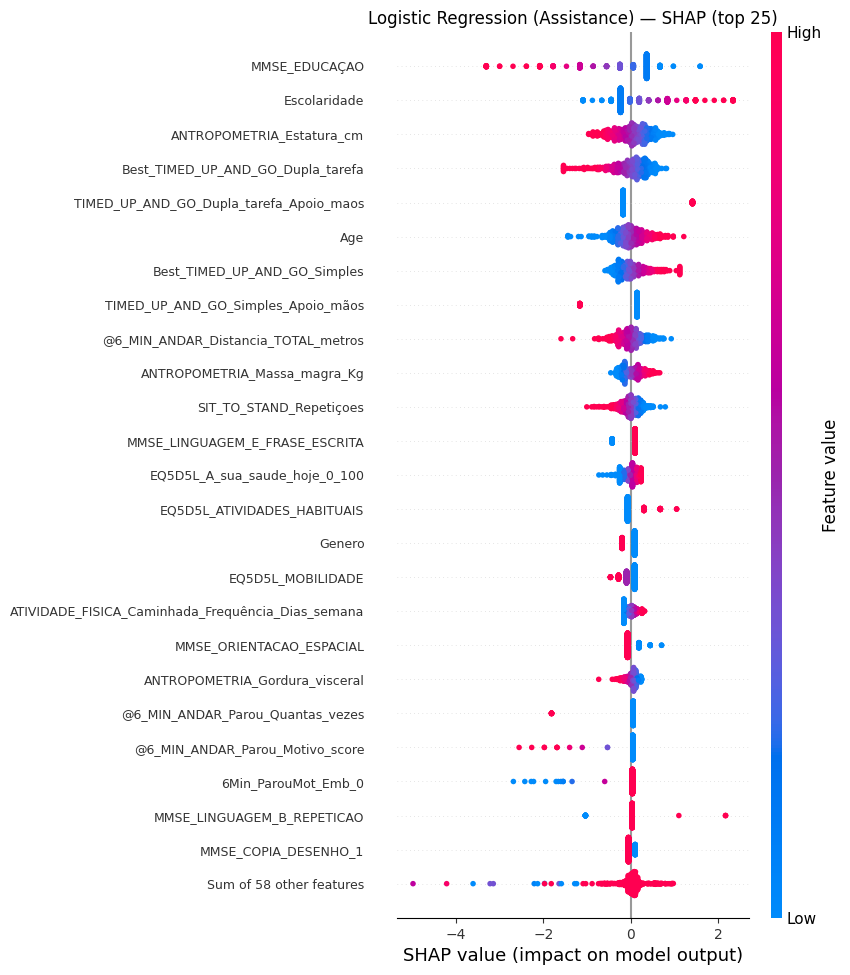


--- Top 10 Risk Factors (Odds Ratio > 1) ---
                                    feature  odds_ratio
48  TIMED_UP_AND_GO_Dupla_tarefa_Apoio_maos    4.887984
45                   HANDGRIP_Mao_DOMINANTE    1.896749
6                              Escolaridade    1.839926
51           MMSE_LINGUAGEM_E_FRASE_ESCRITA    1.688463
1                                       Age    1.467126
11             Best_TIMED_UP_AND_GO_Simples    1.407239
31                      6Min_ParouMot_Emb_0    1.294765
21               MMSE_LINGUAGEM_B_REPETICAO    1.261471
9              ANTROPOMETRIA_Massa_magra_Kg    1.253572
27              EQ5D5L_ATIVIDADES_HABITUAIS    1.222760

--- Top 10 Protective Factors (Odds Ratio < 1) ---
                                    feature  odds_ratio
46       TIMED_UP_AND_GO_Simples_Apoio_mãos    0.269904
47  TIMED_UP_AND_GO_Simples_Auxiliar_marcha    0.286424
17                            MMSE_EDUCAÇAO    0.432000
12        Best_TIMED_UP_AND_GO_Dupla_tarefa    0.639649
4     

In [4]:
# LOGISTIC REGRESSION + SHAP (Target: Hospital Assistance)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import re
from packaging.version import Version

from sklearn import __version__ as skver
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# 0) PREPARE X and y (Assistance Specifics)
# Assuming 'df' is your main dataframe loaded in memory
df_clean = df.copy()

# 1. Define Target
TARGET = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

# 2. Robust Target Check & NaN Handling
if TARGET not in df_clean.columns:
    # Fallback search if exact name is missing
    candidates = [c for c in df_clean.columns if "assistencia_hospitalar" in c.lower()]
    if candidates:
        print(f"⚠️ Exact target not found. Using: {candidates[0]}")
        TARGET = candidates[0]
    else:
        raise KeyError(f"Target '{TARGET}' not found in dataframe.")

print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage safely)
# We use list concatenation (+) instead of * unpacking to avoid TypeErrors

# Basic columns to drop (IDs, Dates, Target)
drop_list = [
    TARGET,
    "ID_Aluno", "Data_avaliacao", "Data_nascimento",
    "Momento"
]

# Leakage: Hospitalization (implies Assistance = Yes)
drop_list += [
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não"
]

# Leakage: Falls (Root cause)
drop_list += [
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Quedas_12meses_Medo_cair_Sim_N_o" # Handle typo variations
]

# Leakage: Post-Fall Details
drop_list += [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade"
]

# Leakage: Project Rules
drop_list += ["@6_MIN_ANDAR_Desistiu"]

# Leakage: Embeddings (Safe construction)
drop_list += [f"Q12M_Sit_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesTipo_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesLocal_Emb_{i}" for i in range(10)]

# Perform Drop (Ignore errors if column is already gone)
X = df_clean.drop(columns=drop_list, errors='ignore')

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split Data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Column Typing
if Version(skver) >= Version("1.2"):
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

num_all = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

binary_cols, continuous_cols = [], []
for c in num_all:
    vals = pd.Series(X_train[c]).dropna().unique()
    if set(np.unique(vals)).issubset({0, 1}):
        binary_cols.append(c)
    else:
        continuous_cols.append(c)

print(f"Continuous: {len(continuous_cols)} | Binary: {len(binary_cols)} | Categorical: {len(cat_cols)}")

# 3) Preprocessor
pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), continuous_cols),
        ("bin", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
        ]), binary_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# 4) Model
logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=None,
    solver="lbfgs"
)

pipe = Pipeline([
    ("pre", pre),
    ("clf", logreg),
])

print("Training Logistic Regression...")
pipe.fit(X_train, y_train)

# 5) Metrics
print("\n--- Performance (Validation) ---")
p_val = pipe.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, p_val)
print(f"AUROC: {auc:.3f}")

# 6) SHAP
X_train_t = pipe.named_steps["pre"].transform(X_train)
X_val_t   = pipe.named_steps["pre"].transform(X_val)

try:
    feat_names = pipe.named_steps["pre"].get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# Sample background data
bg_idx = np.random.RandomState(42).choice(X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False)
background = X_train_t[bg_idx]

print("Calculating SHAP values...")
explainer = shap.LinearExplainer(pipe.named_steps["clf"], background)
sv = explainer(X_val_t)

sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names,
)

# 7) Plot
plt.close("all")
fig, ax = plt.subplots(figsize=(14, 9))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.35)
plt.title("Logistic Regression (Assistance) — SHAP (top 25)")
plt.show()

# 8) Odds Ratios
coef = pipe.named_steps["clf"].coef_.ravel()
coef_df = pd.DataFrame({"feature": feat_names, "coef": coef})
coef_df["odds_ratio"] = np.exp(coef_df["coef"])

print("\n--- Top 10 Risk Factors (Odds Ratio > 1) ---")
print(coef_df.sort_values("coef", ascending=False).head(10)[['feature', 'odds_ratio']])

print("\n--- Top 10 Protective Factors (Odds Ratio < 1) ---")
print(coef_df.sort_values("coef", ascending=True).head(10)[['feature', 'odds_ratio']])

- Let's drop unnecessary columns


AUROC   : 0.632
PR-AUC  : 0.099
Acc@0.5 : 0.659
F1@0.5  : 0.142

Best threshold (by F1): 0.803
F1@best: 0.178

Confusion @0.5
 [[337 168]
 [ 14  15]]

Confusion @best
 [[493  12]
 [ 25   4]]

Classification report @best
              precision    recall  f1-score   support

           0      0.952     0.976     0.964       505
           1      0.250     0.138     0.178        29

    accuracy                          0.931       534
   macro avg      0.601     0.557     0.571       534
weighted avg      0.914     0.931     0.921       534



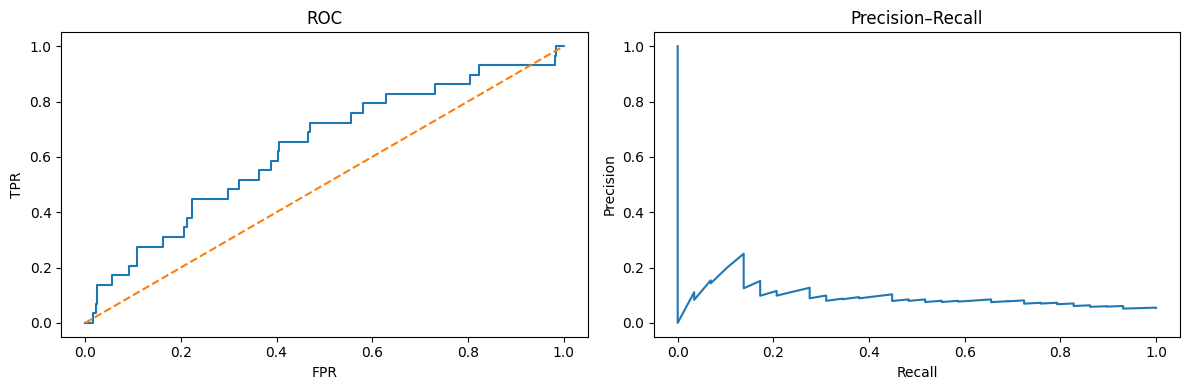

In [5]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt

# Predicted probabilities and default 0.5 labels
proba = pipe.predict_proba(X_val)[:, 1]
pred05 = (proba >= 0.5).astype(int)

# Core metrics
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# ---- Threshold tuning (maximize F1 on the validation set) ----
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
best_ix = np.nanargmax(f1s)
best_thr = thr[best_ix] if best_ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\nBest threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")

# Confusion matrices
print("\nConfusion @0.5\n", confusion_matrix(y_val, pred05))
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))

# Classification report @best
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# ---- Curves (ROC and PR) ----
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()


## XGBoost

Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 54) | y distribution: {0: 2522, 1: 144}

Training XGBoost...
Best iteration: 45
Best score (val): 0.6831000341413451

--- Metrics @0.5 ---
AUROC   : 0.683
PR-AUC  : 0.106
Acc@0.5 : 0.790
F1@0.5  : 0.188

--- Threshold tuning ---
Best threshold (by F1): 0.538
F1@best: 0.218

Confusion @best
 [[444  61]
 [ 18  11]]

Classification report @best
              precision    recall  f1-score   support

           0      0.961     0.879     0.918       505
           1      0.153     0.379     0.218        29

    accuracy                          0.852       534
   macro avg      0.557     0.629     0.568       534
weighted avg      0.917     0.852     0.880       534



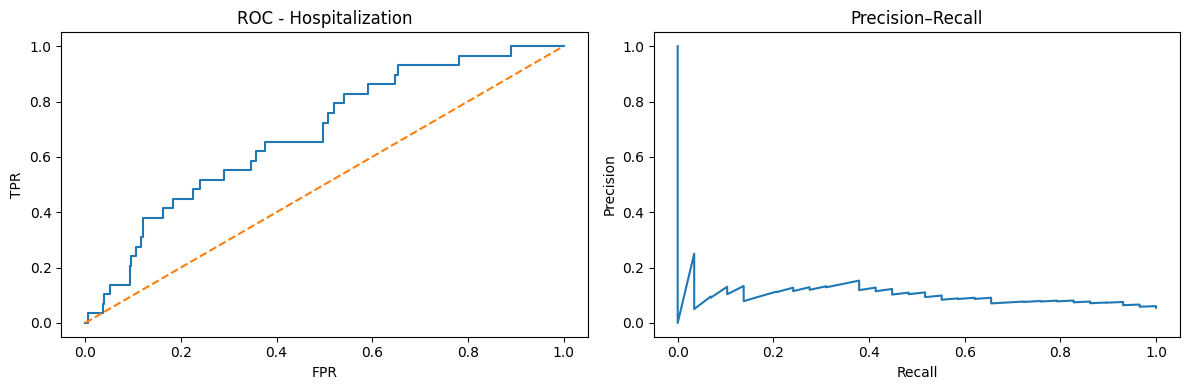

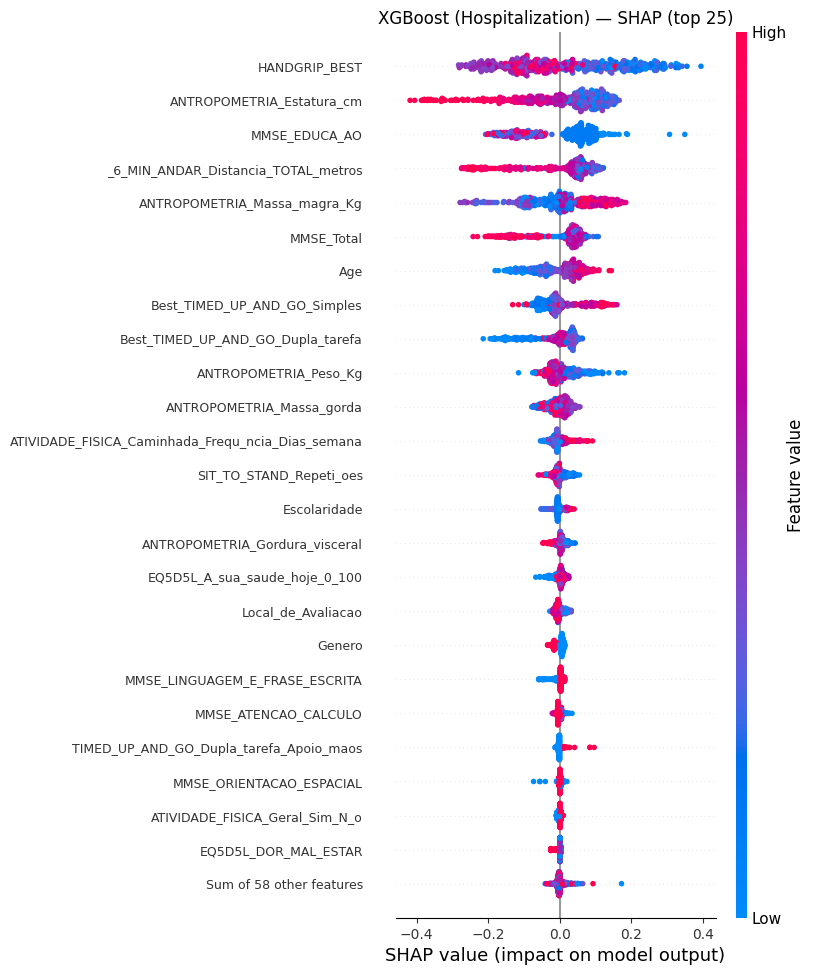

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
import re
from packaging.version import Version

from sklearn import __version__ as skver
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)

# 0) PREPARE X and y (Hospitalization Specifics)
# Assuming 'df' is your main dataframe loaded in memory
df_clean = df.copy()

# 1. Define Target
TARGET = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

# 2. Handle Target NaNs (CRITICAL)
print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y (Force 0/1)
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage)
drop_cols = [
    TARGET,                                          # The target itself
    "ID_Aluno", "Data_avaliacao", "Data_nascimento", # ID/Dates
    
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não",
    
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Momento",
    
    *[f"Q12M_Sit_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesTipo_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesLocal_Emb_{i}" for i in range(10)],
    
    "@6_MIN_ANDAR_Desistiu"
]

existing_to_drop = [c for c in drop_cols if c in df_clean.columns]
X = df_clean.drop(columns=existing_to_drop)

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Pre-processing
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit on train, transform train and val
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# Sanitize feature names for XGBoost (no brackets, spaces, etc.)
clean_feat_names = []
used_names = set()
for name in feat_names:
    s = re.sub(r'[^A-Za-z0-9_]+', '_', name)
    base = s or "f"
    k = base
    i = 1
    while k in used_names:
        k = f"{base}_{i}"
        i += 1
    used_names.add(k)
    clean_feat_names.append(k)

# 
# 3) XGBoost Setup
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
scale_pos_weight = neg / max(pos, 1)  # Critical for rare events like hospitalization

dtrain = xgb.DMatrix(X_train_t, label=y_train, feature_names=clean_feat_names)
dval   = xgb.DMatrix(X_val_t,   label=y_val,   feature_names=clean_feat_names)

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.02,
    "max_depth": 4,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_lambda": 1.0,
    "min_child_weight": 1.0,
    "tree_method": "hist",
    "seed": 42,
    "scale_pos_weight": scale_pos_weight, # Automatically handles the imbalance
}

print("\nTraining XGBoost...")
bst = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=100,
    verbose_eval=False
)

print("Best iteration:", bst.best_iteration)
print("Best score (val):", bst.best_score)

# 4) Metrics
proba = bst.predict(dval, iteration_range=(0, bst.best_iteration + 1))
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Threshold Tuning
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# 5) Curves
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC - Hospitalization")

plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()
# 6) SHAP Beeswarm
try:
    bst.set_attr(base_score="0.5")
except Exception as e:
    print("Warning: could not set base_score for SHAP", e)

# Calculate SHAP
bg_idx = np.random.RandomState(42).choice(
    X_train_t.shape[0], size=min(1000, X_train_t.shape[0]), replace=False
)
explainer = shap.TreeExplainer(bst, data=X_train_t[bg_idx], feature_names=clean_feat_names)
sv = explainer(X_val_t, check_additivity=False)

sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=clean_feat_names),
    feature_names=clean_feat_names,
)

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.40)
plt.title("XGBoost (Hospitalization) — SHAP (top 25)")
plt.show()


## CatBoost

Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 54) | y distribution: {0: 2522, 1: 144}

Training CatBoost...
Best iteration: 113
Best score (val): {'learn': {'Logloss': 0.4124001112855251}, 'validation': {'Logloss': 0.6548878748599866, 'AUC': 0.6886992147490612}}

--- Metrics @0.5 ---
AUROC   : 0.689
PR-AUC  : 0.138
Acc@0.5 : 0.773
F1@0.5  : 0.188

--- Threshold tuning ---
Best threshold (by F1): 0.463
F1@best: 0.195

Confusion @best
 [[358 147]
 [ 10  19]]

Classification report @best
              precision    recall  f1-score   support

           0      0.973     0.709     0.820       505
           1      0.114     0.655     0.195        29

    accuracy                          0.706       534
   macro avg      0.544     0.682     0.508       534
weighted avg      0.926     0.706     0.786       534



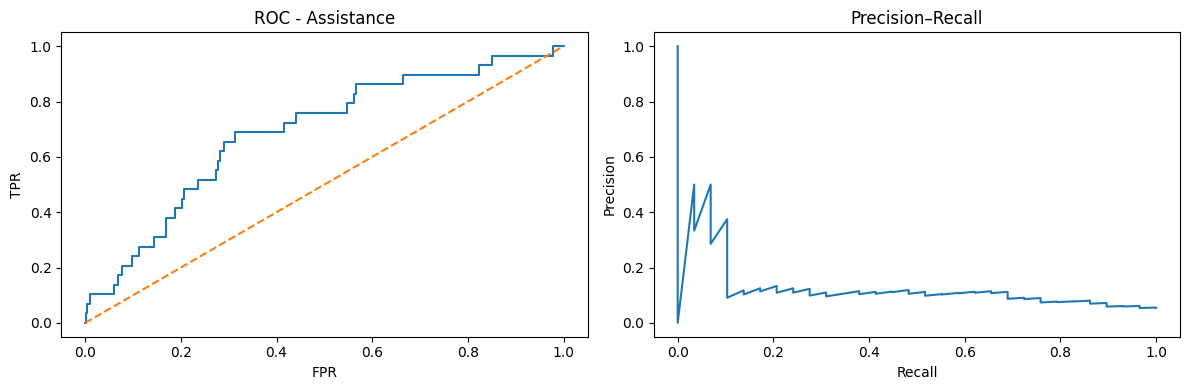

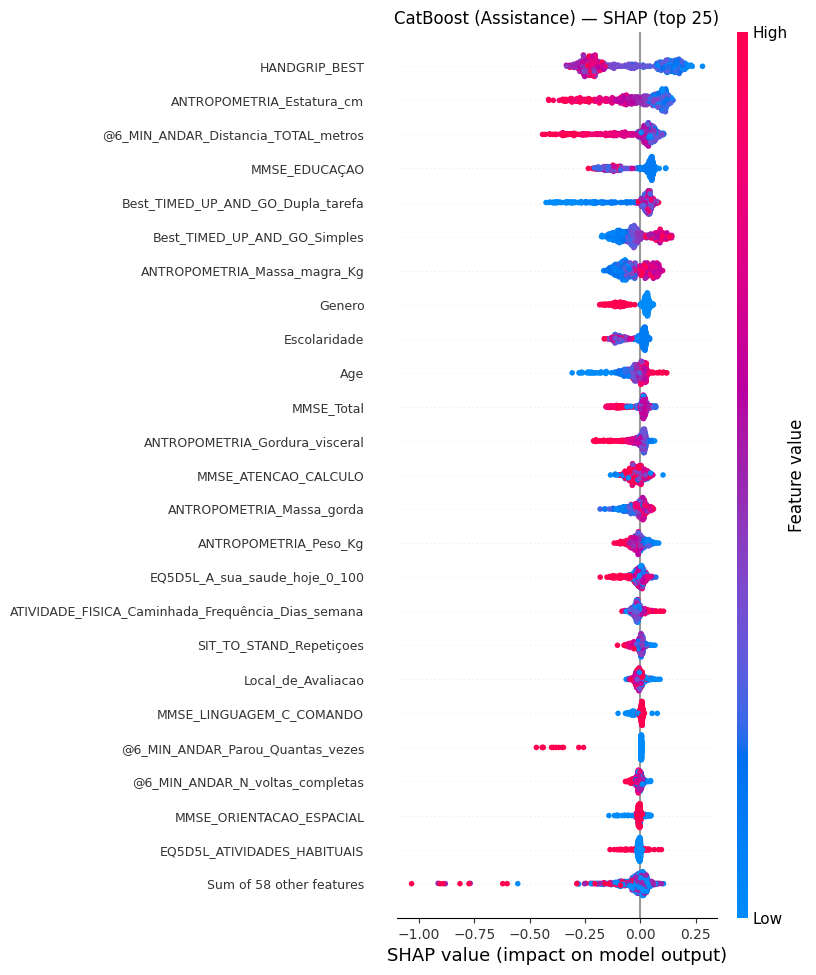

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import re
from packaging.version import Version

# Standard Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)
from sklearn import __version__ as skver

# CatBoost
from catboost import CatBoostClassifier, Pool

# 0) PREPARE X and y (Assistance Specifics)
# Assuming 'df' is your main dataframe loaded in memory
df_clean = df.copy()

# 1. Define Target (Robustly)
TARGET_CANDIDATE = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

if TARGET_CANDIDATE not in df_clean.columns:
    # Fallback: search for similar names
    matches = [c for c in df_clean.columns if "assistencia_hospitalar" in c.lower()]
    if matches:
        print(f"⚠️ Exact target not found. Using: {matches[0]}")
        TARGET = matches[0]
    else:
        raise KeyError(f"Target '{TARGET_CANDIDATE}' not found. Check previous steps.")
else:
    TARGET = TARGET_CANDIDATE

# 2. Handle Target NaNs (CRITICAL)
print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y (Force 0/1)
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage Safely)
# Using list concatenation (+) instead of * unpacking to avoid errors

# Basic drops
drop_list = [
    TARGET,
    "ID_Aluno", "Data_avaliacao", "Data_nascimento",
    "Momento"
]

# Leakage: Hospitalization (implies Assistance = Yes)
drop_list += [
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não"
]

# Leakage: Falls (Root cause)
drop_list += [
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Quedas_12meses_Medo_cair_Sim_N_o"
]

# Leakage: Post-Fall Details
drop_list += [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade"
]

# Leakage: Project Rules
drop_list += ["@6_MIN_ANDAR_Desistiu"]

# Leakage: Embeddings (Safe construction)
drop_list += [f"Q12M_Sit_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesTipo_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesLocal_Emb_{i}" for i in range(10)]

# Drop safely
X = df_clean.drop(columns=drop_list, errors='ignore')

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Pre-processing (Imputation + OHE)
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names for SHAP
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# 3) CatBoost Training
print("\nTraining CatBoost...")
# CatBoost handles imbalance natively with 'auto_class_weights'
clf = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.02,
    depth=6,                 # Standard depth
    loss_function='Logloss',
    eval_metric='AUC',       # Optimize for AUROC
    early_stopping_rounds=100,
    auto_class_weights='Balanced', # Crucial for Assistance (Rare Event)
    verbose=0,               # Silent
    random_seed=42
)

clf.fit(
    X_train_t, y_train,
    eval_set=(X_val_t, y_val),
    use_best_model=True
)

print("Best iteration:", clf.get_best_iteration())
print("Best score (val):", clf.get_best_score())

# 4) Metrics & Threshold Tuning
proba = clf.predict_proba(X_val_t)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Threshold Tuning
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# 5) Curves
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(fpr, tpr); plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC - Assistance")

plt.subplot(1,2,2)
plt.plot(rec, prec)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.tight_layout(); plt.show()

# 6) SHAP for CatBoost
explainer = shap.TreeExplainer(clf)
sv = explainer(X_val_t)

sv = shap.Explanation(
    values=sv.values,
    base_values=sv.base_values,
    data=pd.DataFrame(X_val_t, columns=feat_names),
    feature_names=feat_names
)

plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.40)
plt.title("CatBoost (Assistance) — SHAP (top 25)")
plt.show()

## EBM

Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 54) | y distribution: {0: 2522, 1: 144}
Training EBM... (This might take a moment)

--- Metrics @0.5 ---
AUROC   : 0.634
PR-AUC  : 0.106
Acc@0.5 : 0.946
F1@0.5  : 0.000

--- Threshold tuning ---
Best threshold (by F1): 0.11
F1@best: 0.200

Confusion @best
 [[480  25]
 [ 23   6]]

Classification report @best
              precision    recall  f1-score   support

           0      0.954     0.950     0.952       505
           1      0.194     0.207     0.200        29

    accuracy                          0.910       534
   macro avg      0.574     0.579     0.576       534
weighted avg      0.913     0.910     0.912       534



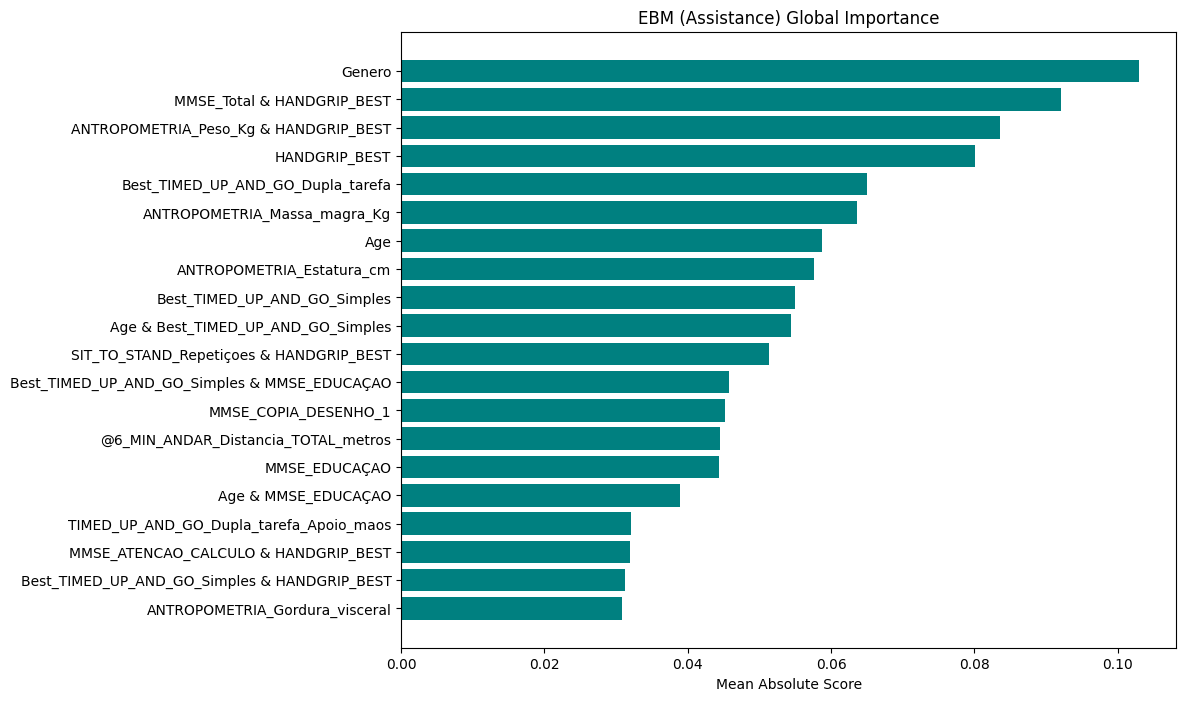

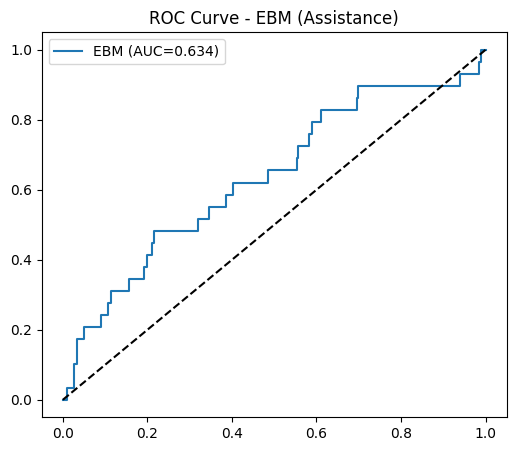

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from packaging.version import Version

from sklearn import __version__ as skver
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)

# EBM Imports
from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

# 0) PREPARE X and y (Assistance Specifics)
# Assuming 'df' is your main dataframe loaded in memory
df_clean = df.copy()

# 1. Define Target (Robustly)
TARGET_CANDIDATE = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

if TARGET_CANDIDATE not in df_clean.columns:
    # Fallback search
    matches = [c for c in df_clean.columns if "assistencia_hospitalar" in c.lower()]
    if matches:
        print(f"⚠️ Exact target not found. Using: {matches[0]}")
        TARGET = matches[0]
    else:
        raise KeyError(f"Target '{TARGET_CANDIDATE}' not found.")
else:
    TARGET = TARGET_CANDIDATE

# 2. Handle Target NaNs (CRITICAL)
print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y (Force 0/1)
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage Safely)
# Using list concatenation (+) to avoid syntax errors

# Basic drops
drop_list = [
    TARGET,
    "ID_Aluno", "Data_avaliacao", "Data_nascimento",
    "Momento"
]

# Leakage: Hospitalization (implies Assistance = Yes)
drop_list += [
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não"
]

# Leakage: Falls (Root cause)
drop_list += [
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Quedas_12meses_Medo_cair_Sim_N_o"
]

# Leakage: Post-Fall Details
drop_list += [
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade"
]

# Leakage: Project Rules
drop_list += ["@6_MIN_ANDAR_Desistiu"]

# Leakage: Embeddings (Safe construction)
drop_list += [f"Q12M_Sit_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesTipo_Emb_{i}" for i in range(10)]
drop_list += [f"Q12M_LesLocal_Emb_{i}" for i in range(10)]

# Drop safely
X = df_clean.drop(columns=drop_list, errors='ignore')

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Pre-processing (Imputation + OHE)
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Get feature names (Crucial for EBM graphs)
try:
    feat_names = pre.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_t.shape[1])]

# 3) EBM Training
print("Training EBM... (This might take a moment)")

# EBM handles imbalanced data naturally, but 'outer_bags' helps smoothing
ebm = ExplainableBoostingClassifier(
    feature_names=feat_names,
    interactions=10,       # Automatically detects top 10 pair-interactions
    outer_bags=8,          # Ensembling (smoothing)
    inner_bags=0,
    learning_rate=0.01, 
    max_rounds=2000,       # Similar to n_estimators
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1              # Use all cores
)

ebm.fit(X_train_t, y_train)

# 4) Metrics & Threshold Tuning
proba = ebm.predict_proba(X_val_t)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Threshold Tuning
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix  = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# 5) Global Explanation
ebm_global = ebm.explain_global()

# Extract top feature importances manually for a static plot
importances = ebm_global.data()['scores']
names = ebm_global.data()['names']

# Sort by importance
imp_df = pd.DataFrame({'feature': names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(imp_df['feature'], imp_df['importance'], color='teal')
plt.gca().invert_yaxis()
plt.title("EBM (Assistance) Global Importance")
plt.xlabel("Mean Absolute Score")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"EBM (AUC={roc_auc_score(y_val, proba):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.title("ROC Curve - EBM (Assistance)")
plt.show()

# NOTE: To see the interactive dashboard, run this in a new cell:
# from interpret import show
# show(ebm_global)



# SVM



Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 56) | y distribution: {0: 2522, 1: 144}
Training SVM with RBF Kernel...

--- Metrics @0.5 ---
AUROC   : 0.639
PR-AUC  : 0.159
Acc@0.5 : 0.946
F1@0.5  : 0.000

--- Threshold tuning ---
Best threshold (by F1): 0.112
F1@best: 0.231

Confusion @best
 [[488  17]
 [ 23   6]]

Classification report @best
              precision    recall  f1-score   support

           0      0.955     0.966     0.961       505
           1      0.261     0.207     0.231        29

    accuracy                          0.925       534
   macro avg      0.608     0.587     0.596       534
weighted avg      0.917     0.925     0.921       534



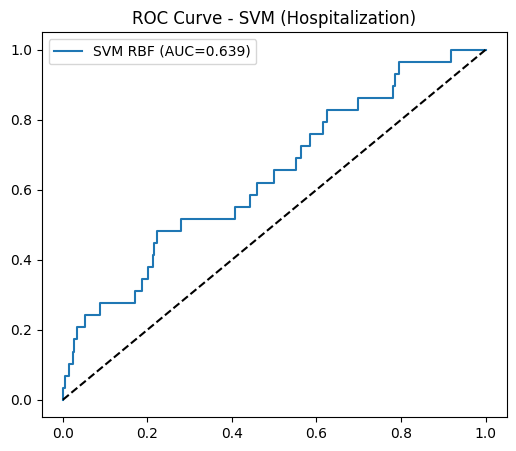

c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(



Calculating SHAP values (KernelExplainer is slow, please wait)...


  0%|          | 0/534 [00:00<?, ?it/s]c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
  0%|          | 1/534 [00:00<07:24,  1.20it/s]c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
  0%|     

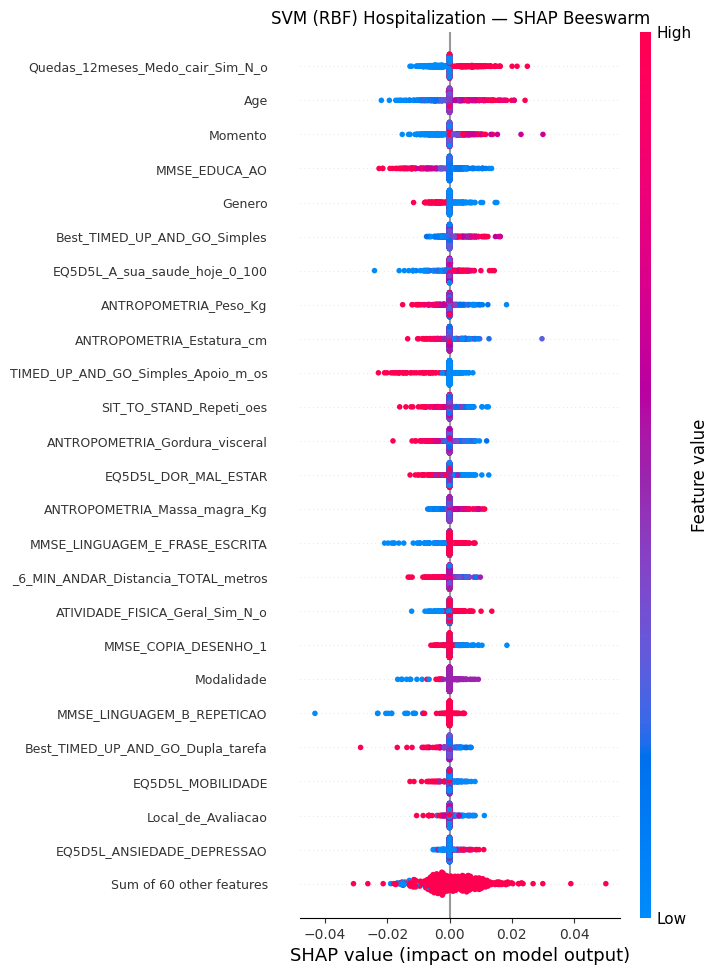

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import re
from packaging.version import Version

from sklearn import __version__ as skver
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, accuracy_score,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report
)

# 0) PREPARE X and y (Hospitalization Specifics)
# Assuming 'df' is your main dataframe loaded in memory
df_clean = df.copy()

# 1. Define Target
TARGET = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

# 2. Handle Target NaNs (CRITICAL)
print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y (Force 0/1)
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage)
drop_cols = [
    TARGET,                                          # The target itself
    "ID_Aluno", "Data_avaliacao", "Data_nascimento", # ID/Dates
    
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não",
    
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade",
    
    *[f"Q12M_Sit_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesTipo_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesLocal_Emb_{i}" for i in range(10)],
    
    "@6_MIN_ANDAR_Desistiu"
]

existing_to_drop = [c for c in drop_cols if c in df_clean.columns]
X = df_clean.drop(columns=existing_to_drop)

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# =======================
# 2) Pre-processing (StandardScaler is Mandatory for SVM)
# =======================
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        # SVM requires data to be scaled (mean=0, var=1)
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) 
        ]), num_cols),
        
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Fit and Transform
X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# Feature Naming & Cleaning
try:
    raw_names = pre.get_feature_names_out().tolist()
except:
    raw_names = [f"f{i}" for i in range(X_train_t.shape[1])]

clean_names = []
used = set()
for n in raw_names:
    # Sanitize names (replace special chars with _)
    s = re.sub(r'[^A-Za-z0-9_]+', '_', n)
    k = s if s not in used else f"{s}_dup"
    i = 1
    while k in used: # Ensure absolute uniqueness
        k = f"{s}_{i}"
        i += 1
    used.add(k)
    clean_names.append(k)

# Convert to DataFrames for easier SHAP handling
X_train_df = pd.DataFrame(X_train_t, columns=clean_names)
X_val_df   = pd.DataFrame(X_val_t, columns=clean_names)

# 3) Train SVM (RBF)
print("Training SVM with RBF Kernel...")
# probability=True is required for SHAP to explain probabilities
# class_weight='balanced' handles the imbalanced medical data
model_svm = SVC(
    kernel='rbf', 
    probability=True, 
    class_weight='balanced', 
    C=1.0, 
    random_state=42
)
model_svm.fit(X_train_df, y_train)

# 
# 4) Metrics & Threshold Tuning
proba = model_svm.predict_proba(X_val_df)[:, 1]
pred05 = (proba >= 0.5).astype(int)

print("\n--- Metrics @0.5 ---")
print("AUROC   :", f"{roc_auc_score(y_val, proba):.3f}")
print("PR-AUC  :", f"{average_precision_score(y_val, proba):.3f}")
print("Acc@0.5 :", f"{accuracy_score(y_val, pred05):.3f}")
print("F1@0.5  :", f"{f1_score(y_val, pred05):.3f}")

# Tune Threshold for Best F1
prec, rec, thr = precision_recall_curve(y_val, proba)
f1s = 2*prec*rec/(prec+rec + 1e-12)
ix = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5
pred_best = (proba >= best_thr).astype(int)

print("\n--- Threshold tuning ---")
print("Best threshold (by F1):", round(float(best_thr), 3))
print("F1@best:", f"{f1_score(y_val, pred_best):.3f}")
print("\nConfusion @best\n", confusion_matrix(y_val, pred_best))
print("\nClassification report @best")
print(classification_report(y_val, pred_best, digits=3))

# Plot ROC
fpr, tpr, _ = roc_curve(y_val, proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SVM RBF (AUC={roc_auc_score(y_val, proba):.3f})")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve - SVM (Hospitalization)")
plt.legend()
plt.show()

# 5) SHAP Beeswarm (KernelExplainer)
print("\nCalculating SHAP values (KernelExplainer is slow, please wait)...")


background_data = shap.sample(X_train_df, 100, random_state=42)

def predict_proba_fn(data):
    return model_svm.predict_proba(data)[:, 1]

explainer = shap.KernelExplainer(predict_proba_fn, background_data)

# Explain the validation set (using only 100 samples for speed)
shap_values = explainer.shap_values(X_val_df, nsamples=100)

sv = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_val_df,
    feature_names=clean_names
)

# Plot Beeswarm
plt.close("all")
fig, ax = plt.subplots(figsize=(12, 10))
shap.plots.beeswarm(sv, max_display=25, show=False)
plt.yticks(fontsize=9); plt.xticks(fontsize=10); plt.subplots_adjust(left=0.40)
plt.title("SVM (RBF) Hospitalization — SHAP Beeswarm")
plt.show()

Let's now apply shapiro wilk as diferenças entee os modelos para ver realmente as diferenças entre performances

## Neural Network (MLP)

Original shape: (2666, 102)
Shape after dropping NaNs in 'Quedas_12meses_Assistencia_hospitalar_Sim_Não': (2666, 102)
X shape: (2666, 54) | y distribution: {0: 2522, 1: 144}
Training Neural Network...
Epoch 1/150


c:\Users\tiago1951\Desktop\Projeto_saude_geriatrica\saude_geriatrica\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - auc: 0.5119 - loss: 0.9418 - val_auc: 0.5755 - val_loss: 0.7929
Epoch 2/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5747 - loss: 0.8546 - val_auc: 0.5624 - val_loss: 0.7735
Epoch 3/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5872 - loss: 0.8278 - val_auc: 0.5551 - val_loss: 0.7658
Epoch 4/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5985 - loss: 0.8288 - val_auc: 0.5640 - val_loss: 0.7597
Epoch 5/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - auc: 0.5516 - loss: 0.8436 - val_auc: 0.5723 - val_loss: 0.7589
Epoch 6/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6268 - loss: 0.7852 - val_auc: 0.5797 - val_loss: 0.7543
Epoch 7/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6705 - loss: 0.7447 - val_auc: 0.5974 - val_loss: 0.7521
Epoch 8/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.6267 - loss: 0.7841 - val_auc: 0.6192 - val_loss: 0.7347
Epoch 9/150
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - auc: 0.5942 - loss: 0.8

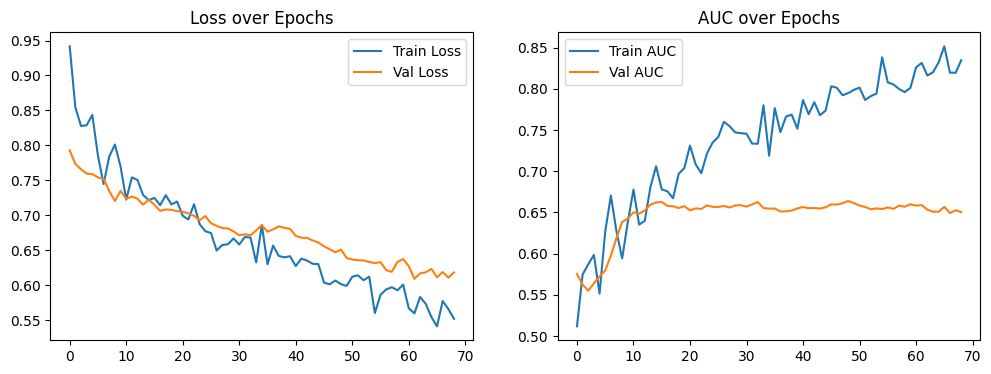

In [10]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, 
    confusion_matrix, precision_recall_curve, f1_score, accuracy_score
)
from sklearn import __version__ as skver
from packaging.version import Version
import re

# 0) PREPARE X and y (Hospitalization Specifics)
df_clean = df.copy()

# 1. Define Target
TARGET = "Quedas_12meses_Assistencia_hospitalar_Sim_Não"

# 2. Handle Target NaNs (CRITICAL)
print(f"Original shape: {df_clean.shape}")
df_clean = df_clean.dropna(subset=[TARGET])
print(f"Shape after dropping NaNs in '{TARGET}': {df_clean.shape}")

# 3. Define y (Force 0/1)
try:
    y = df_clean[TARGET].astype(int)
except:
    map_dict = {'Sim': 1, 'Não': 0, 'Yes': 1, 'No': 0, 1.0: 1, 0.0: 0}
    y = df_clean[TARGET].map(map_dict).fillna(0).astype(int)

# 4. Define X (Drop Leakage)
drop_cols = [
    TARGET,                                          # The target itself
    "ID_Aluno", "Data_avaliacao", "Data_nascimento", # ID/Dates
    
    "Quedas_12meses_Hospitalizado_Dias",
    "Quedas_12meses_Hospitalizado_Sim_Não",
    
    "Quedas_ultimos_12meses", 
    "Quedas_12meses",
    
    "Quedas_12meses_Quantas",
    "Quedas_12meses_Situacao",
    "Quedas_12meses_Lesao_Sim_Nao",
    "Quedas_12meses_Lesao_Tipo",
    "Quedas_12meses_Lesao_Local",
    "Quedas_12meses_Lesao_Gravidade",
    "Quedas_12meses_Situacao_score",
    "Quedas_12meses_Lesao_Local_Gravidade",
    "Quedas_12meses_Medo_cair_Sim_Não",
    "Momento",
    
    *[f"Q12M_Sit_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesTipo_Emb_{i}" for i in range(10)],
    *[f"Q12M_LesLocal_Emb_{i}" for i in range(10)],
    
    "@6_MIN_ANDAR_Desistiu"
]

existing_to_drop = [c for c in drop_cols if c in df_clean.columns]
X = df_clean.drop(columns=existing_to_drop)

print(f"X shape: {X.shape} | y distribution: {y.value_counts().to_dict()}")

# 1) Split train/val
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 2) Pre-processing (Must use Scaling for NN)
def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        # Neural Nets REQUIRE Standard Scaling (mean=0, var=1)
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) 
        ]), num_cols),
        
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_t = pre.fit_transform(X_train)
X_val_t   = pre.transform(X_val)

# 3) Define the Neural Network Structure
def build_model(input_dim):
    model = models.Sequential()
    
    # Layer 1: Wide layer
    model.add(layers.Dense(64, input_dim=input_dim, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))  # Higher dropout for rare target
    
    # Layer 2: Bottleneck
    model.add(layers.Dense(32, kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4))
    
    # Output Layer: Sigmoid
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly lower LR for stability
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    return model

# 4) Train with Early Stopping
print("Training Neural Network...")

# Calculate class weights for imbalance
pos = int((y_train == 1).sum())
neg = int((y_train == 0).sum())
total = pos + neg
# Weight for class 0
w0 = (1 / neg) * (total / 2.0)
# Weight for class 1
w1 = (1 / pos) * (total / 2.0)
class_weights = {0: w0, 1: w1}

model = build_model(X_train_t.shape[1])

# Stop training if validation AUC doesn't improve for 20 epochs
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', 
    patience=20, 
    mode='max', 
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_t, y_train,
    validation_data=(X_val_t, y_val),
    epochs=150,            # Increased epochs since LR is lower
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

# 5) Detailed Results & Metrics
proba_nn = model.predict(X_val_t).flatten()

print("\n--- Neural Network Performance Analysis (Hospitalization) ---")
nn_auc = roc_auc_score(y_val, proba_nn)
print(f"AUROC: {nn_auc:.3f}")

# Find Best Threshold (maximizing F1)
prec, rec, thr = precision_recall_curve(y_val, proba_nn)
f1s = 2 * prec * rec / (prec + rec + 1e-12)
ix = np.nanargmax(f1s)
best_thr = thr[ix] if ix < len(thr) else 0.5

print(f"Best Threshold (by F1): {best_thr:.3f}")

# Apply Threshold
preds_nn = (proba_nn >= best_thr).astype(int)
nn_pr_auc = average_precision_score(y_val, proba_nn)  # <-- ADD THIS
# Confusion Matrix
cm = confusion_matrix(y_val, preds_nn)
tn, fp, fn, tp = cm.ravel()

# Calculate Metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
accuracy = accuracy_score(y_val, preds_nn)
f1 = f1_score(y_val, preds_nn)

print("\n--- Detailed Metrics ---")
print(f"Sensitivity (Recall): {sensitivity:.3f}")
print(f"Specificity         : {specificity:.3f}")
print(f"Precision           : {precision:.3f}")
print(f"F1 Score            : {f1:.3f}")
print(f"Accuracy            : {accuracy:.3f}")
print(f"PR-AUC: {nn_pr_auc:.3f}")  # <-- ADD THIS
print("\nConfusion Matrix:")
print(cm)
print(f"[TN: {tn}, FP: {fp}]")
print(f"[FN: {fn}, TP: {tp}]")

print("\nClassification Report:")
print(classification_report(y_val, preds_nn, digits=3))

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC over Epochs')
plt.legend()
plt.show()

## Statistical Comparison between models

In [11]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn import __version__ as skver
from packaging.version import Version
import re
import warnings

# Ignorar avisos para limpar a saída
warnings.filterwarnings('ignore')

# 1. Preparação dos Dados (Scaling Universal)
# Para comparação justa, vamos usar o pipeline que inclui Scaling (necessário para SVM)
# Árvores não são afetadas negativamente pelo scaling.

def make_ohe():
    if Version(skver) >= Version("1.2"):
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()) # Standard scaling para todos
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("ohe", make_ohe()),
        ]), cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

# Transformar todo o dataset X
X_processed = preprocessor.fit_transform(X)

# Limpeza de nomes das features
try:
    raw_names = preprocessor.get_feature_names_out().tolist()
except:
    raw_names = [f"f{i}" for i in range(X_processed.shape[1])]

feature_names = []
used = set()
for n in raw_names:
    s = re.sub(r'[^A-Za-z0-9_]+', '_', n)
    k = s if s not in used else f"{s}_dup"
    i = 1
    while k in used:
        k = f"{s}_{i}"
        i += 1
    used.add(k)
    feature_names.append(k)

# Converter para DataFrame (necessário para CatBoost/EBM/XGB por vezes)
X_df = pd.DataFrame(X_processed, columns=feature_names)
y_series = pd.Series(y).reset_index(drop=True)

# 2. Definição dos Modelos
# Configurações otimizadas das etapas anteriores

# Pesos para balanceamento (Global)
pos = int((y_series == 1).sum())
neg = int((y_series == 0).sum())
scale_pos_weight = neg / max(pos, 1)

models = {
    "XGBoost": xgb.XGBClassifier(
        objective="binary:logistic", eval_metric="auc", 
        n_estimators=1000, learning_rate=0.02, max_depth=4, 
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=1000, learning_rate=0.02, depth=6, eval_metric='AUC',
        auto_class_weights='Balanced', verbose=0, random_seed=42, allow_writing_files=False
    ),
    "EBM": ExplainableBoostingClassifier(
        feature_names=feature_names, interactions=10, outer_bags=8, 
        learning_rate=0.01, max_rounds=1000, random_state=42, n_jobs=1
    ),
    "SVM (RBF)": SVC(
        kernel='rbf', probability=True, class_weight='balanced', 
        C=1.0, random_state=42
    )
}

# 3. Loop de 10-Fold CV
print("A iniciar 10-Fold Cross-Validation...")
print("Isto pode demorar alguns minutos devido ao treino repetido.")

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Dicionário para guardar os scores de cada fold
cv_results = {name: [] for name in models.keys()}
cv_results["Ensemble"] = []

fold = 1
for train_idx, val_idx in kf.split(X_df, y_series):
    X_tr, X_val = X_df.iloc[train_idx], X_df.iloc[val_idx]
    y_tr, y_val = y_series.iloc[train_idx], y_series.iloc[val_idx]
    
    fold_probs = [] # Para guardar probs deste fold para o ensemble
    
    # Treinar cada modelo individualmente
    for name, model in models.items():
        # Clone ou re-instanciar seria ideal, mas fit() geralmente reinicia
        try:
            model.fit(X_tr, y_tr)
        except:
            # Fallback para EBM/CatBoost se precisarem de eval_set específico
            model.fit(X_tr, y_tr)
            
        # Predição
        if name == "SVM (RBF)" or name == "EBM":
            p = model.predict_proba(X_val)[:, 1]
        else:
            p = model.predict_proba(X_val)[:, 1]
            
        auc = roc_auc_score(y_val, p)
        cv_results[name].append(auc)
        fold_probs.append(p)
    
    # Calcular Ensemble deste fold (Média Simples)
    ens_p = np.mean(fold_probs, axis=0)
    ens_auc = roc_auc_score(y_val, ens_p)
    cv_results["Ensemble"].append(ens_auc)
    
    print(f"Fold {fold}/10 Concluído - Ensemble AUC: {ens_auc:.3f}")
    fold += 1

# 4. Análise Estatística (O Algoritmo Solicitado)
print("\n" + "="*60)
print("RESULTADOS DA COMPARAÇÃO ESTATÍSTICA PAR-A-PAR")
print("="*60)
print(f"{'Comparação':<30} | {'Diferença Média':<15} | {'Teste Usado':<20} | {'p-value':<10} | {'Significativo?'}")
print("-" * 100)

model_names = list(cv_results.keys())
significant_findings = []

# Iterar por todos os pares únicos
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        
        scores_a = np.array(cv_results[name_a])
        scores_b = np.array(cv_results[name_b])
        
        # Diferenças (Fold a Fold)
        diff = scores_a - scores_b
        mean_diff = np.mean(diff)
        
        # 1. Teste de Normalidade (Shapiro-Wilk) nas diferenças
        # Se p > 0.05, assumimos normalidade
        shapiro_stat, shapiro_p = stats.shapiro(diff)
        is_normal = shapiro_p > 0.05
        
        # 2. Escolha do Teste
        if is_normal:
            # Paramétrico: Paired t-test
            test_stat, p_val = stats.ttest_rel(scores_a, scores_b)
            test_name = "Paired t-test"
        else:
            # Não-Paramétrico: Wilcoxon Signed-Rank
            test_stat, p_val = stats.wilcoxon(scores_a, scores_b)
            test_name = "Wilcoxon"
            
        is_sig = "SIM" if p_val < 0.05 else "Não"
        
        print(f"{name_a} vs {name_b:<18} | {mean_diff:+.4f}          | {test_name:<20} | {p_val:.4f}     | {is_sig}")
        
        if p_val < 0.05:
            winner = name_a if mean_diff > 0 else name_b
            significant_findings.append(f"-> {winner} é estatisticamente superior a {name_a if winner == name_b else name_b} (p={p_val:.4f})")

print("\nRESUMO DAS DESCOBERTAS SIGNIFICATIVAS (p < 0.05):")
if not significant_findings:
    print("Nenhuma diferença estatisticamente significativa encontrada entre os modelos.")
    print("Isto sugere que os modelos têm desempenhos muito semelhantes (overlapping confidence intervals).")
else:
    for finding in significant_findings:
        print(finding)

# Mostrar médias finais
print("\nMédias de AUC (10-Folds):")
metrics_df = pd.DataFrame(cv_results)
print(metrics_df.mean().sort_values(ascending=False))

A iniciar 10-Fold Cross-Validation...
Isto pode demorar alguns minutos devido ao treino repetido.
Fold 1/10 Concluído - Ensemble AUC: 0.628
Fold 2/10 Concluído - Ensemble AUC: 0.541
Fold 3/10 Concluído - Ensemble AUC: 0.666
Fold 4/10 Concluído - Ensemble AUC: 0.670
Fold 5/10 Concluído - Ensemble AUC: 0.662
Fold 6/10 Concluído - Ensemble AUC: 0.590
Fold 7/10 Concluído - Ensemble AUC: 0.643
Fold 8/10 Concluído - Ensemble AUC: 0.602
Fold 9/10 Concluído - Ensemble AUC: 0.634
Fold 10/10 Concluído - Ensemble AUC: 0.536

RESULTADOS DA COMPARAÇÃO ESTATÍSTICA PAR-A-PAR
Comparação                     | Diferença Média | Teste Usado          | p-value    | Significativo?
----------------------------------------------------------------------------------------------------
XGBoost vs CatBoost           | +0.0070          | Paired t-test        | 0.5031     | Não
XGBoost vs EBM                | -0.0408          | Paired t-test        | 0.0433     | SIM
XGBoost vs SVM (RBF)          | -0.0103         